In [37]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [39]:
# Load datasets
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
order_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
products = pd.read_csv("../data/raw/olist_products_dataset.csv")
payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")
reviews = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")
sellers = pd.read_csv("../data/raw/olist_sellers_dataset.csv")

In [41]:
# Getting Columns of a dataset as a list
order_columns_list = orders.columns.tolist()
print(order_columns_list)
print(len(order_columns_list))

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
8


In [154]:
print(customers.columns)

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')


In [59]:
# info about the columns
orders.info()
# number of missing values in each column
orders.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [43]:
# Storing all the datasets in one dictionary
datasets = {
    "Customers": customers,
    "Orders": orders,
    "Order Items": order_items,
    "Products": products,
    "Payments": payments,
    "Reviews": reviews,
    "Sellers": sellers
}

In [45]:
# Initial check of the datasets
for name, df in datasets.items():
    print("=" * 60)
    print(name)
    print("=" * 60)

    print("\nShape")
    print(df.shape)

    print("\nFirst Five Rows")
    print(df.head())

    print("\nInformation")
    print(df.info())

    print("\nMissing Values")
    print(df.isnull().sum())

    print("\nDuplicates")
    print(df.duplicated().sum())

    print("\n")

Customers

Shape
(99441, 5)

First Five Rows
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  

Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total

In [47]:
# Descriptive Statistics for each of the datasets
for name, df in datasets.items():
    print("=" * 20)
    print(name)
    print("=" * 20)

    print(df.describe(include="all"))

Customers
                             customer_id                customer_unique_id  \
count                              99441                             99441   
unique                             99441                             96096   
top     06b8999e2fba1a1fbc88172c00ba8bc7  8d50f5eadf50201ccdcedfb9e2ac8455   
freq                                   1                                17   
mean                                 NaN                               NaN   
std                                  NaN                               NaN   
min                                  NaN                               NaN   
25%                                  NaN                               NaN   
50%                                  NaN                               NaN   
75%                                  NaN                               NaN   
max                                  NaN                               NaN   

        customer_zip_code_prefix customer_city custom

In [51]:
# Convert Date Columns from object datatype to datetime datatype
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

reviews["review_creation_date"] = pd.to_datetime(
    reviews["review_creation_date"]
)

reviews["review_answer_timestamp"] = pd.to_datetime(
    reviews["review_answer_timestamp"]
)

order_items["shipping_limit_date"] = pd.to_datetime(
    order_items["shipping_limit_date"]
)

print("Done changing the datatype!")

Done changing the datatype!


In [55]:
# Missing Values Report
missing_report = pd.DataFrame()

for name, df in datasets.items():

    temp = pd.DataFrame({
        "Column": df.columns,
        "Missing Values": df.isnull().sum().values,
        "Missing Percentage":
            np.round(df.isnull().mean().values * 100, 2)
    })

    temp["Dataset"] = name

    missing_report = pd.concat(
        [missing_report, temp],
        ignore_index=True
    )

missing_report.sort_values(
    by="Missing Percentage",
    ascending=False
)

,Column,Missing Values,Missing Percentage,Dataset
37,review_comment_title,87656,88.34,Reviews
38,review_comment_message,58247,58.70,Reviews
11,order_delivered_customer_date,2965,2.98,Orders
22,product_name_lenght,610,1.85,Products
24,product_photos_qty,610,1.85,Products
23,product_description_lenght,610,1.85,Products
21,product_category_name,610,1.85,Products
10,order_delivered_carrier_date,1783,1.79,Orders
9,order_approved_at,160,0.16,Orders
26,product_length_cm,2,0.01,Products


In [57]:
# Remove Duplicate Rows
for name, df in datasets.items():

    before = len(df)

    df.drop_duplicates(inplace=True)

    after = len(df)

    print(
        f"{name}: Removed {before-after} duplicate rows"
    )

Customers: Removed 0 duplicate rows
Orders: Removed 0 duplicate rows
Order Items: Removed 0 duplicate rows
Products: Removed 0 duplicate rows
Payments: Removed 0 duplicate rows
Reviews: Removed 0 duplicate rows
Sellers: Removed 0 duplicate rows


In [61]:
# Handle Missing Values
products["product_category_name"] = products[
    "product_category_name"
].fillna("Unknown")

reviews["review_comment_title"] = reviews[
    "review_comment_title"
].fillna("No Title")

reviews["review_comment_message"] = reviews[
    "review_comment_message"
].fillna("No Comment")

In [85]:
# trying to check if the missing data has been handled

# products["product_category_name"].unique()

# print("Before:")
# print(products["product_category_name"].isnull().sum())

# products["product_category_name"] = products["product_category_name"].fillna("Unknown")

# print("After:")
# print(products["product_category_name"].isnull().sum())

Before:
0
After:
0


In [63]:
# Create Business Features
# A feature is simply new information derived from existing data.

# 1. Delivery Time
orders["delivery_days"] = (
    orders["order_delivered_customer_date"] -
    orders["order_purchase_timestamp"]
).dt.days

# 2. Approval Time
orders["approval_days"] = (
    orders["order_approved_at"] -
    orders["order_purchase_timestamp"]
).dt.days

# 3. Purchase Month
orders["purchase_month"] = (
    orders["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

# 4. Purchase Year
orders["purchase_year"] = (
    orders["order_purchase_timestamp"]
    .dt.year
)

# 5. Purchase Quarter
orders["purchase_quarter"] = (
    orders["order_purchase_timestamp"]
    .dt.quarter
)


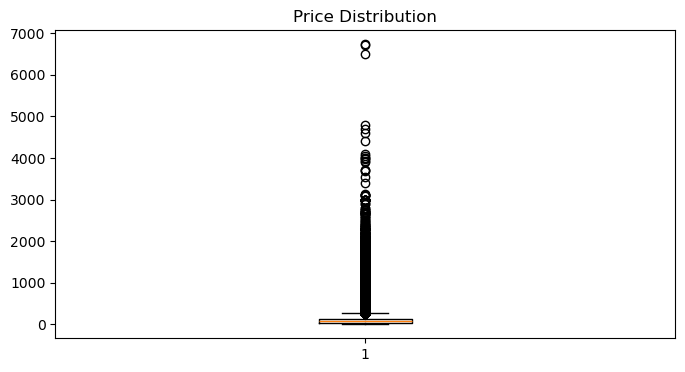

In [65]:
# Outlier Detection
plt.figure(figsize=(8,4))

plt.boxplot(order_items["price"])

plt.title("Price Distribution")

plt.show()

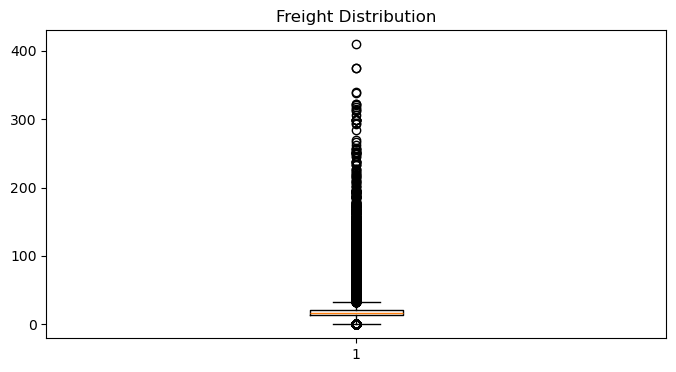

In [67]:
plt.figure(figsize=(8,4))

plt.boxplot(order_items["freight_value"])

plt.title("Freight Distribution")

plt.show()

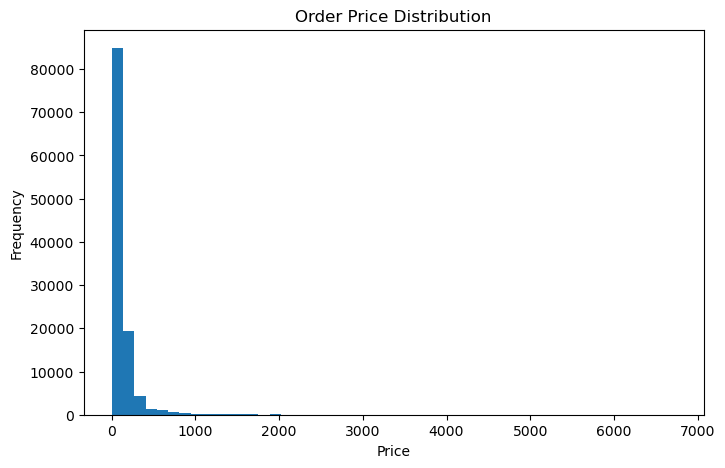

In [69]:
# Revenue Distribution
plt.figure(figsize=(8,5))

plt.hist(order_items["price"], bins=50)

plt.title("Order Price Distribution")

plt.xlabel("Price")

plt.ylabel("Frequency")

plt.show()

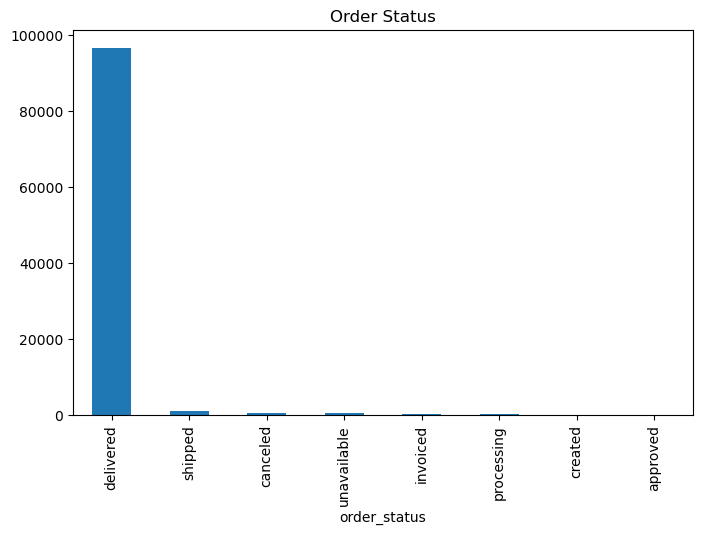

In [71]:
# Order Status
orders["order_status"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Order Status")

plt.show()

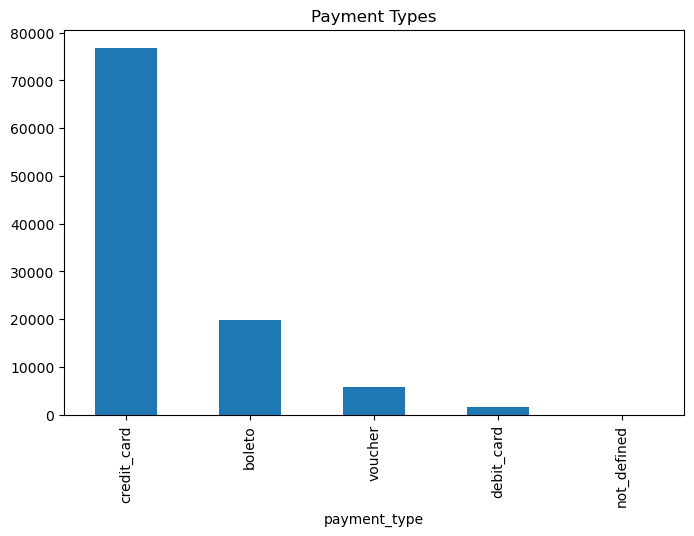

In [73]:
# Payment Methods
payments["payment_type"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Payment Types")

plt.show()

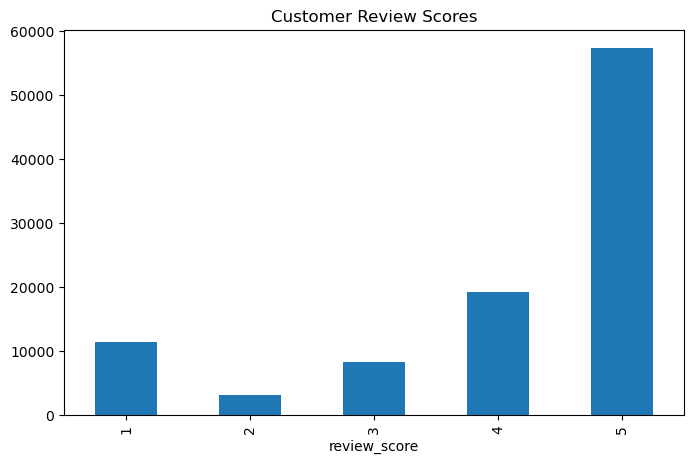

In [75]:
# Review Scores
reviews["review_score"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Customer Review Scores")

plt.show()

In [77]:
# Save Cleaned Files
customers.to_csv(
    "../data/processed/customers_cleaned.csv",
    index=False
)

orders.to_csv(
    "../data/processed/orders_cleaned.csv",
    index=False
)

order_items.to_csv(
    "../data/processed/order_items_cleaned.csv",
    index=False
)

products.to_csv(
    "../data/processed/products_cleaned.csv",
    index=False
)

payments.to_csv(
    "../data/processed/payments_cleaned.csv",
    index=False
)

reviews.to_csv(
    "../data/processed/reviews_cleaned.csv",
    index=False
)

sellers.to_csv(
    "../data/processed/sellers_cleaned.csv",
    index=False
)

In [128]:
print(orders.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_days', 'approval_days', 'purchase_month', 'purchase_year', 'purchase_quarter']


In [130]:
print(orders['order_status'].unique())

['delivered' 'invoiced' 'shipped' 'processing' 'unavailable' 'canceled'
 'created' 'approved']


## Business-Focused Exploratory Data Analysis (EDA)

In [90]:
# How many orders does the company have?
print(f"Total Orders: {orders['order_id'].nunique():,}")
# The business needs to know its transaction volume.
# This gives the overall scale of business operations.

Total Orders: 99,441


In [94]:
# How many customers?
print(f"Total Customers: {customers['customer_unique_id'].nunique():,}")
# Businesses care about customers, not just orders.

Total Customers: 96,096


In [96]:
# How many sellers?
print(f"Total Sellers: {sellers['seller_id'].nunique():,}")
# Marketplace growth.

Total Sellers: 3,095


In [136]:
# Total Revenue.
# Only include the orders with order_status "delivered"
delivered_orders = orders[
    orders["order_status"] == "delivered"
]
# Then merge:
sales = delivered_orders.merge(
    order_items,
    on="order_id"
)
# Now calculate total revenue
total_revenue = order_items["price"].sum()
print(f"Total Revenue: $ {total_revenue:,.2f}")
# Revenue was calculated using the sum of product prices.

Total Revenue: $ 13,591,643.70


In [152]:
# Average Order Value
# Merge payments with orders.
avg_order_value = (
    payments.groupby("order_id")["payment_value"]
    .sum()
    .mean()
)
print(f"Average Order Value: R$ {avg_order_value:.2f}")
# AOV is one of the most common e-commerce KPIs.

Average Order Value: R$ 160.99


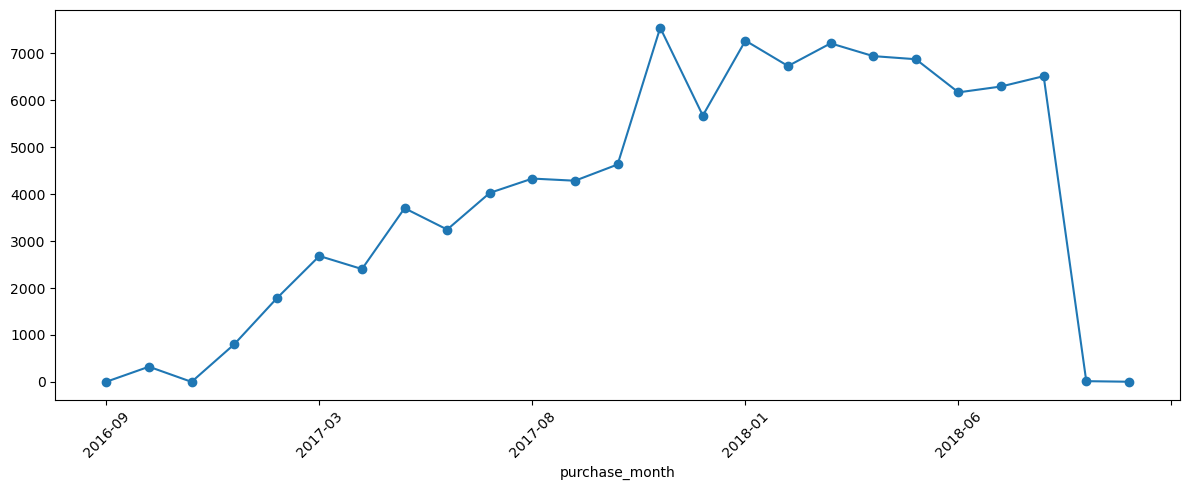

In [138]:
# Monthly Orders Trend
monthly_orders = (
    orders.groupby("purchase_month")
    .size()
)

# Visualization
monthly_orders.plot(
    figsize=(12,5),
    marker="o"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# Is the business growing?
# Monthly trends help identify seasonality and growth patterns.

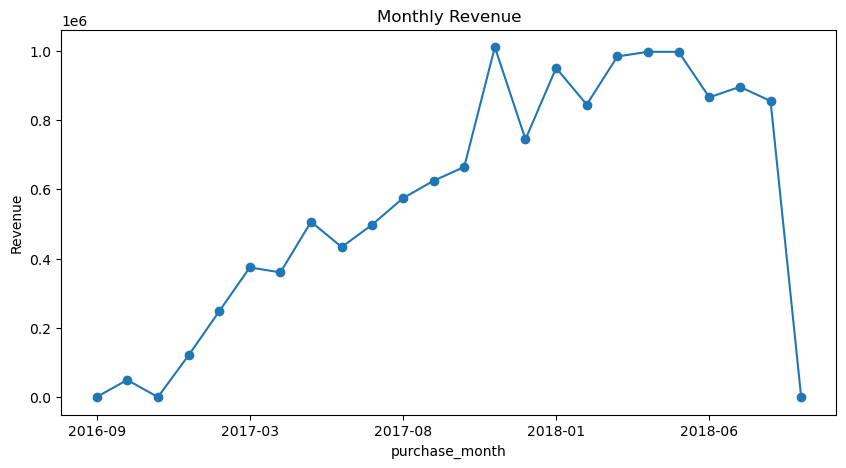

In [110]:
# Monthly Revenue
# merge first
sales = order_items.merge(
    orders[["order_id", "purchase_month"]],
    on="order_id"
)
# Revenue
monthly_sales = (
    sales.groupby("purchase_month")["price"]
    .sum()
)
# Plot:
monthly_sales.plot(
    figsize=(10,5),
    marker="o"
)

plt.title("Monthly Revenue")

plt.ylabel("Revenue")

plt.show()

In [ ]:
for month in sales["purchase_month"].unique():
    print(sales["price"].sum())

# Another way without group by not recommended

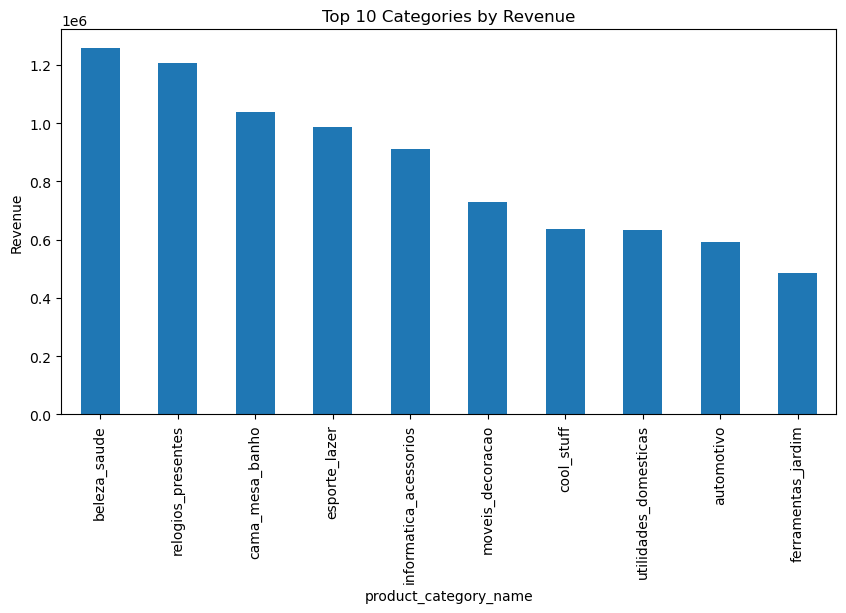

In [112]:
# Top 10 Product Categories
category_sales = (
    order_items
    .merge(products, on="product_id")
    .groupby("product_category_name")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Visualize
category_sales.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Categories by Revenue")

plt.ylabel("Revenue")

plt.show()

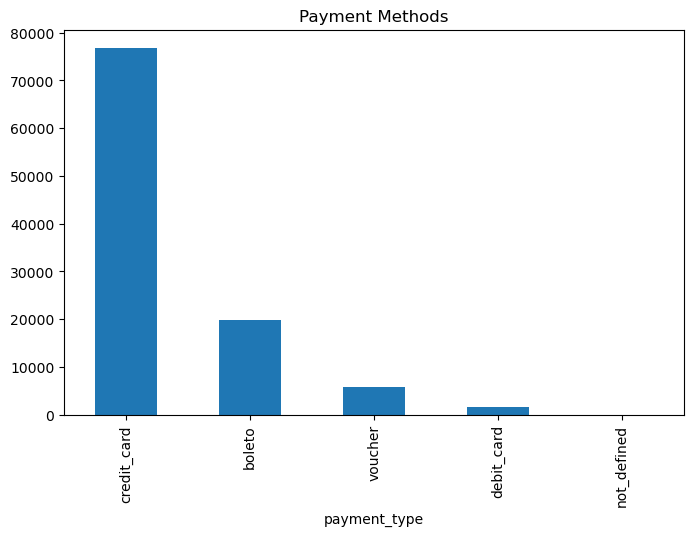

In [114]:
# Payment Method Usage
payments["payment_type"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Payment Methods")

plt.show()
# Which payment methods should be promoted?

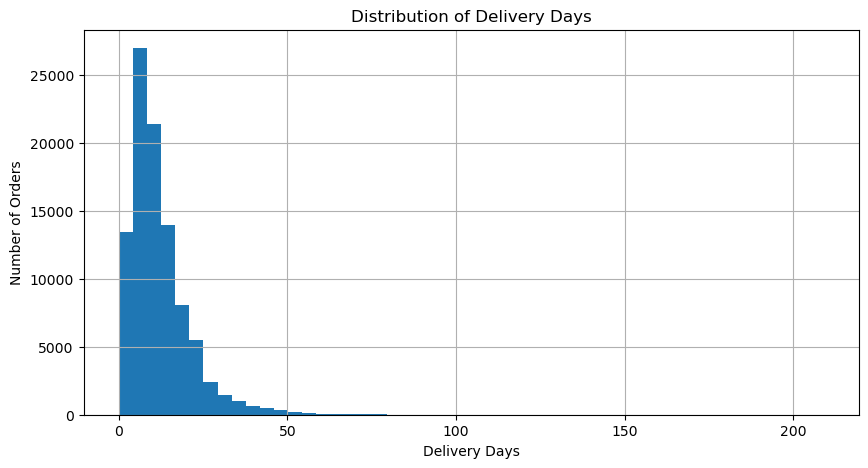

In [150]:
# Delivery Performance
orders["delivery_days"].describe()
# Visualization:
orders["delivery_days"].hist(
    bins=50,
    figsize=(10,5)
)

plt.xlabel("Delivery Days")
plt.ylabel("Number of Orders")
plt.title("Distribution of Delivery Days")
plt.show()
# How quickly are orders delivered?

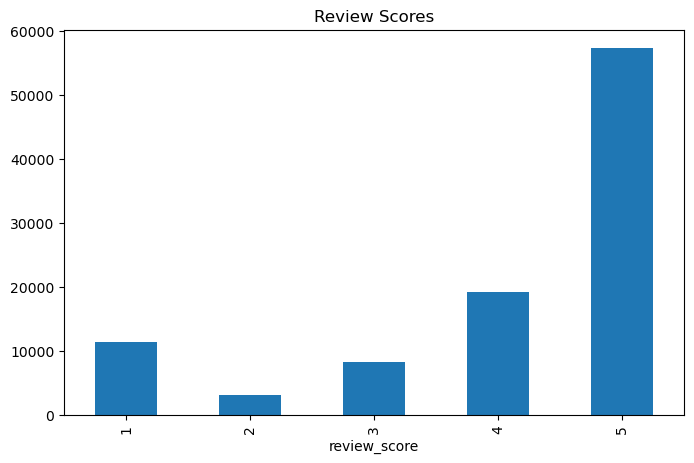

In [120]:
# Customer Satisfaction
reviews["review_score"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Review Scores")

plt.show()
# Are customers generally happy?

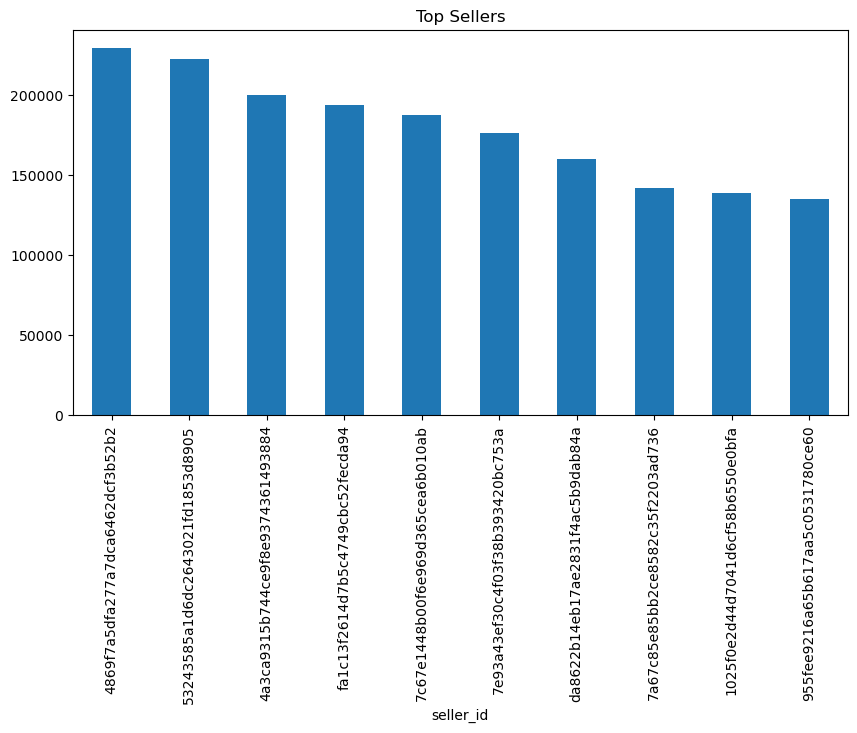

In [126]:
# Top Sellers
top_sellers = (
    order_items.groupby("seller_id")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
# Plot.
top_sellers.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top Sellers")

plt.show()